<a href="https://colab.research.google.com/github/AAlokshukla179/Airbnb-/blob/main/Airbub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New section

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
df = pd.read_csv("/content/1730285881-Airbnb_Open_Data.csv")
df.head()

/tmp/ipython-input-1836782488.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/1730285881-Airbnb_Open_Data.csv")


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,19-10-2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,21-05-2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,05-07-2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,19-11-2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [13]:
print("The Shape of the dataset:",df.shape)

The Shape of the dataset: (34059, 26)


Clean Data


In [14]:
print("Nulls present in the dataset column wise")
df.isnull().sum()

Nulls present in the dataset column wise


,0
id,0
NAME,117
host id,0
host_identity_verified,158
host name,225
neighbourhood group,27
neighbourhood,16
lat,8
long,8
country,88


In [15]:
df.isnull().sum()

,0
id,0
NAME,117
host id,0
host_identity_verified,158
host name,225
neighbourhood group,27
neighbourhood,16
lat,8
long,8
country,88


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34059 entries, 0 to 34058
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              34059 non-null  int64  
 1   NAME                            33942 non-null  object 
 2   host id                         34059 non-null  int64  
 3   host_identity_verified          33901 non-null  object 
 4   host name                       33834 non-null  object 
 5   neighbourhood group             34032 non-null  object 
 6   neighbourhood                   34043 non-null  object 
 7   lat                             34051 non-null  float64
 8   long                            34051 non-null  float64
 9   country                         33971 non-null  object 
 10  country code                    33979 non-null  object 
 11  instant_bookable                33979 non-null  object 
 12  cancellation_policy             

In [17]:
df.duplicated().value_counts()

,count
False,34059


In [27]:
df.drop_duplicates(inplace=True)
df.rename(columns={'service fee':'service_fee_$'},inplace=True)

In [30]:
df.drop_duplicates(inplace=True)

#Drop all records with missing values
df.dropna(inplace=True)

#Change all mismatched data types to the appropriate once
df['price_$']=df['price_$'].astype(float)
df['service_fee_$']=df['service_fee_$'].astype(float)
df['id']=df['id'].astype(str)
df['host id']=df['host id'].astype(str)
df['last review']=pd.to_datetime(df['last review'])
df['Construction year']=df['Construction year'].astype(int)

In [33]:
df.duplicated().value_counts()

,count
False,27410


# New section

In [34]:
df.describe()

,lat,long,Construction year,price_$,service_fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,27410.000000,27410.000000,27410.000000,27410.000000,27410.000000,27410.000000,27410.000000,27410,27410.000000,27410.000000,27410.000000,27410.000000
mean,40.728259,-73.952755,2012.482379,623.379387,124.678840,6.501715,35.462495,2018-07-14 07:21:58.905508864,1.100355,3.139912,3.303940,152.189566
min,40.508680,-74.239860,2003.000000,50.000000,10.000000,-12.000000,1.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,40.688230,-73.982108,2008.000000,336.000000,67.000000,2.000000,4.000000,2017-11-24 00:00:00,0.130000,2.000000,1.000000,12.000000
50%,40.721570,-73.955520,2012.000000,619.500000,124.000000,3.000000,13.000000,2019-03-02 00:00:00,0.450000,3.000000,1.000000,127.000000
75%,40.763550,-73.937760,2017.000000,912.000000,182.000000,5.000000,46.000000,2019-06-19 00:00:00,1.580000,4.000000,2.000000,274.000000
max,40.908040,-73.712990,2022.000000,1200.000000,240.000000,1250.000000,629.000000,2022-05-21 00:00:00,19.750000,5.000000,232.000000,426.000000
std,0.054788,0.043792,5.758021,332.908332,66.585388,20.085588,52.764148,NaN,1.454360,1.360144,10.751314,135.878408


What are the different type of Property

In [35]:
property_type = df['room type'].value_counts().to_frame()
property_type

,count
room type,
Entire home/apt,14631
Private room,12297
Shared room,482


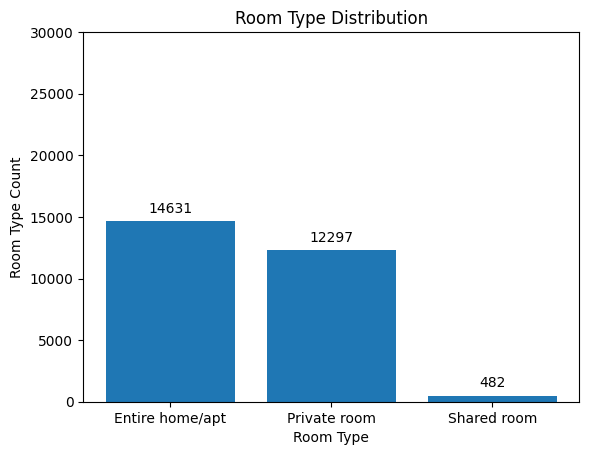

In [37]:
room_type_bar = plt.bar(property_type.index,property_type.loc[:,"count"]);
plt.bar_label(room_type_bar,labels = property_type.loc[:,"count"],padding=4);
plt.ylim([0,30000]);
plt.xlabel('Room Type');
plt.ylabel('Room Type Count');
plt.title('Room Type Distribution');

Which neighborhood group has the highest number of listings?


In [38]:
hood_group = df['neighbourhood group'].value_counts().to_frame()
hood_group

,count
neighbourhood group,
Brooklyn,11956
Manhattan,11799
Queens,2914
Bronx,543
Staten Island,197
brookln,1


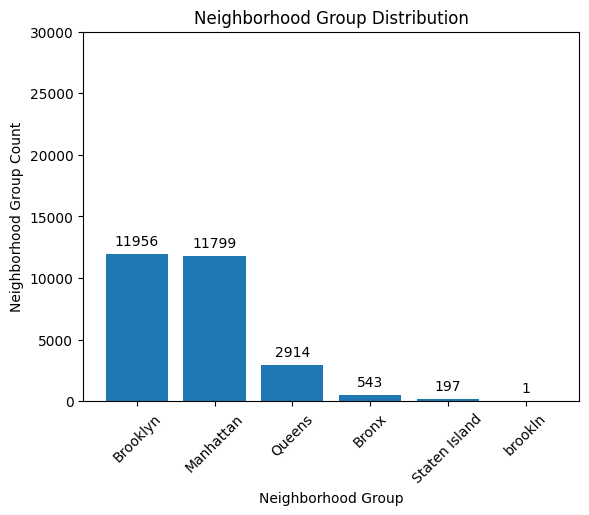

In [39]:
hood_group_bar = plt.bar(hood_group.index,hood_group.loc[:,"count"]);
plt.bar_label(hood_group_bar,labels = hood_group.loc[:,"count"],padding=4);
plt.ylim([0,30000]);
plt.xlabel('Neighborhood Group');
plt.ylabel('Neighborhood Group Count');
plt.xticks(rotation=45);
plt.title('Neighborhood Group Distribution');

Which neighborhoods group have the highest average prices for Airbnb Listigs?

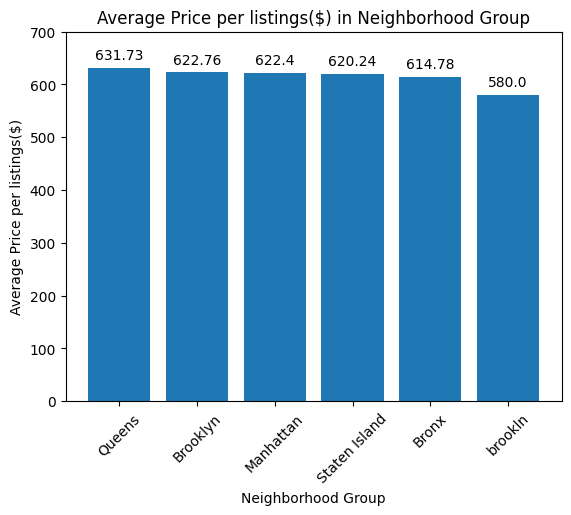

In [40]:
avg_price = df.groupby('neighbourhood group')['price_$'].mean().sort_values(ascending= False).to_frame()
avg_price_bar = plt.bar(avg_price.index,avg_price.loc[:,"price_$"]);
plt.bar_label(avg_price_bar,labels = round(avg_price.loc[:,"price_$"],2),label_type='edge',padding=4);
plt.ylim([0,700]);
plt.xlabel('Neighborhood Group');
plt.ylabel('Average Price per listings($)');
plt.xticks(rotation=45);
plt.title('Average Price per listings($) in Neighborhood Group');

Is there a relationship between the construction year of property and price?

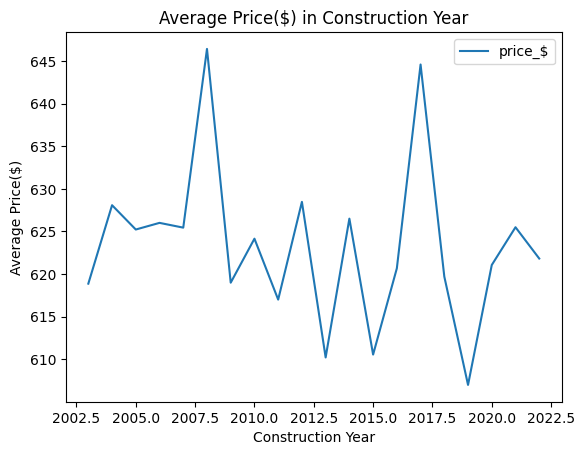

In [42]:
df.groupby(df['Construction year'])['price_$'].mean().to_frame().plot();
plt.xlabel('Construction Year');
plt.ylabel('Average Price($)');
plt.title('Average Price($) in Construction Year');

The line plot shows the constrution year of properties vs the average price per property reveals a downward trend in prices as the construction year progress.

Who are the Top 10 hosts?

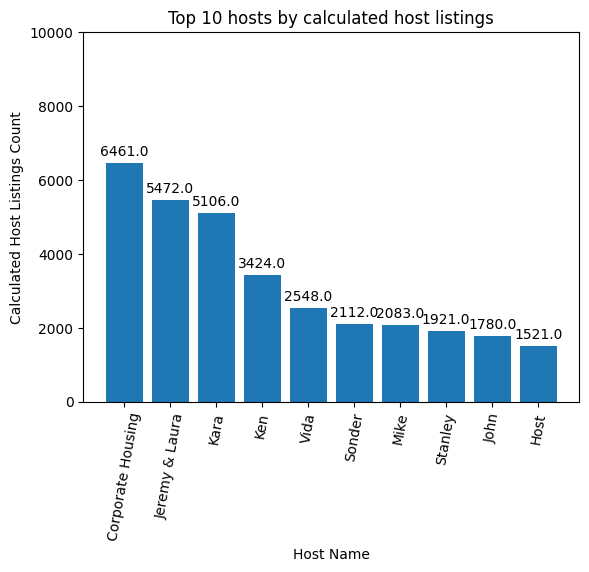

In [47]:
hosts = df.groupby('host name')['calculated host listings count'].sum().sort_values(ascending= False ).nlargest(10).to_frame()
hosts_bar = plt.bar(hosts.index,hosts.loc[:,"calculated host listings count"]);
plt.bar_label(hosts_bar,labels = hosts.loc[:,"calculated host listings count"],label_type='edge',padding=3);
plt.xlabel('Host Name');
plt.ylabel('Calculated Host Listings Count');
plt.xticks(rotation=80);
plt.ylim([0,10000]);
plt.title('Top 10 hosts by calculated host listings');

Are hosts with verified identities more likely to receive positive reviews?

In [48]:
review = df.groupby('host_identity_verified')['number of reviews'].mean().sort_values(ascending= False).to_frame()
review

,number of reviews
host_identity_verified,
unconfirmed,35.532360
verified,35.391996


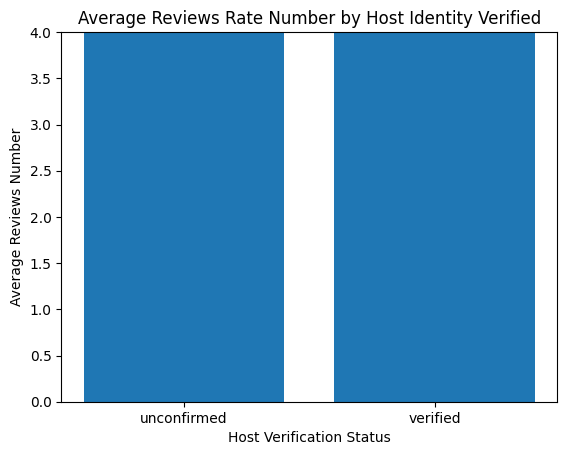

In [50]:
review_bar = plt.bar(review.index,review.loc[:,"number of reviews"]);
plt.bar_label(review_bar,labels = round(review.loc[:,"number of reviews"],2),padding=4);
plt.ylim([0,4]);
plt.xlabel('Host Verification Status');
plt.ylabel('Average Reviews Number');
plt.title('Average Reviews Rate Number by Host Identity Verified');

Is there a correlation between the price of a listing and its service fee?

In [52]:
correlation = df['price_$'].corr(df['service_fee_$'])
print(f"The correlation between price and service fee is: {correlation}")

The correlation between price and service fee is: 0.9999909922413817


Text(0.5, 1.0, 'Correalation of Price vs Service Fee')

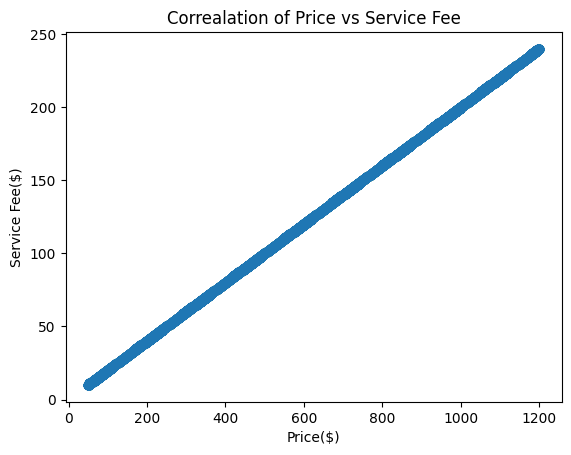

In [53]:
sns.regplot(df, x = 'price_$', y = 'service_fee_$');
plt.xlabel('Price($)');
plt.ylabel('Service Fee($)');
plt.title('Correalation of Price vs Service Fee')

What is the avg review rate number for listings, and does it vary based on the neighborhood group and room type?

In [54]:
ARRN = df.groupby(['neighbourhood group','room type'])['review rate number'].mean().to_frame()
ARRN

review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            3.288660
                    Private room               3.171171
                    Shared room                3.000000
Brooklyn            Entire home/apt            3.098628
                    Private room               3.164958
                    Shared room                3.113636
Manhattan           Entire home/apt            3.118254
                    Private room               3.157311
                    Shared room                3.182243
Queens              Entire home/apt            3.160526
                    Private room               3.177752
                    Shared room                3.360000
Staten Island       Entire home/apt            3.189474
                    Private room               3.465347
                    Shared room                5.000000
brookln             Private room               4.000000

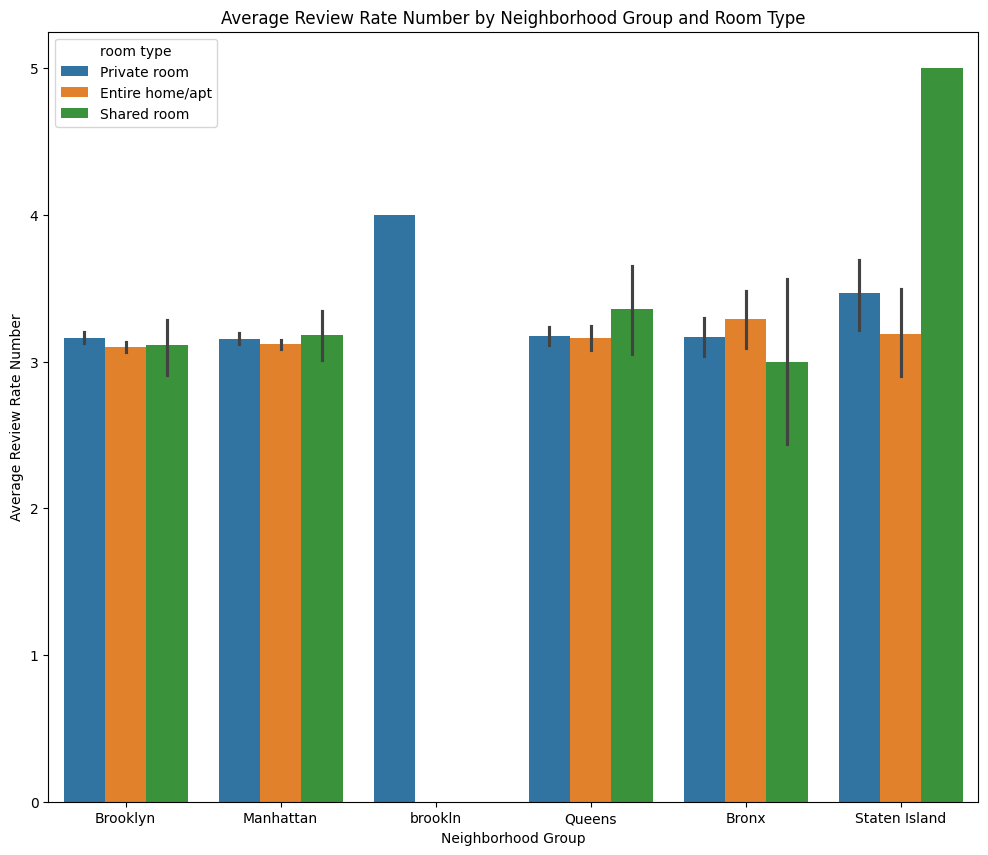

In [55]:
plt.figure(figsize=(12, 10));
sns.barplot(data=df, x= 'neighbourhood group', y= 'review rate number', hue= 'room type');
plt.xlabel('Neighborhood Group');
plt.ylabel('Average Review Rate Number');
plt.title('Average Review Rate Number by Neighborhood Group and Room Type');